In [189]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt

In [190]:
df = pd.read_json(r'D:\IMP  ML  PROJECTS\CAR PRICE PREDICTION\web scraping\car_dataset_ahmedabad.json')

In [191]:
req_cols = []
with open (r'features.txt', 'r') as f:
    features = f.read().split('\n')
for i in features:
    if i in df.columns:
        req_cols.append(i)
df = df[req_cols]
df.to_csv('dataset.csv')

In [192]:
df = pd.read_csv('dataset.csv')
df.head()

,Unnamed: 0,Engine,No. of Cylinders,Valves Per Cylinder,Valve Configuration,Fuel Supply System,Fuel Type,Engine Type,Emission Norm Compliance,Kerb Weight,Drive Type,Transmission,Power
0,0,1197 cc,4.0,4.0,DOHC,MPFI,Petrol,Kappa VTVT Petrol Engine,BS IV,935 kg,FWD,Manual,82 bhp
1,1,1086 cc,4.0,3.0,SOHC,MPFI,Petrol,IRDE2 Engine,BS IV,860 kg,FWD,Manual,68.05 bhp
2,2,1196 cc,4.0,4.0,DOHC,SEFI,Petrol,Petrol Engine,BS IV,1090 kg,Front Wheel Drive,Manual,70 bhp
3,3,1197 cc,4.0,4.0,DOHC,MPFI,Petrol,Kappa VTVT Petrol Engine,NaN,1060 kg,FWD,Manual,81.86 bhp
4,4,936 cc,3.0,4.0,DOHC,Direct Injection,Diesel,SMARTECH Diesel Engine,BS IV,1025 kg,FWD,Manual,56.3 bhp


In [193]:
df.columns

Index(['Unnamed: 0', 'Engine', 'No. of Cylinders', 'Valves Per Cylinder',
       'Valve Configuration', 'Fuel Supply System', 'Fuel Type', 'Engine Type',
       'Emission Norm Compliance', 'Kerb Weight', 'Drive Type', 'Transmission',
       'Power'],
      dtype='object')

In [194]:
df.drop('Unnamed: 0', axis=1, inplace=True)

In [195]:
# Print percentage missing in each feature
for col in df.columns:
    print(f'{col}: {df[col].isnull().sum() / len(df) * 100}')
    

Engine: 1.303538175046555
No. of Cylinders: 0.8379888268156425
Valves Per Cylinder: 0.8379888268156425
Valve Configuration: 31.00558659217877
Fuel Supply System: 27.37430167597765
Fuel Type: 0.186219739292365
Engine Type: 3.072625698324022
Emission Norm Compliance: 13.966480446927374
Kerb Weight: 7.82122905027933
Drive Type: 13.594040968342643
Transmission: 0.186219739292365
Power: 2.8864059590316575


In [196]:
def one_hot_encode_with_info(df, column_name, prefix=None):
    
    if prefix is None:
        prefix = column_name

    # get categories
    categories = sorted(df[column_name].dropna().unique())

    print(f"\nFeature: {column_name}")
    print("All Categories:", categories)

    dropped_category = categories[0]
    print("Dropped Category:", dropped_category)

    # create dummies
    dummies = pd.get_dummies(
        df[column_name],
        prefix=prefix,
        drop_first=True
    )

    # add to dataframe
    df = pd.concat([df, dummies], axis=1)

    # drop original column
    df.drop(columns=[column_name], inplace=True)

    return df, dropped_category

1. Engine

In [197]:
df["Engine"] = (
    df["Engine"]
    .astype(str)
    .str.replace(r"[^\d.]", "", regex=True)    
)

df["Engine"] = pd.to_numeric(df["Engine"], errors="coerce")
df['Engine'].fillna(df['Engine'].median(), inplace=True)

2. No. of Cylinders

In [198]:
df['No. of Cylinders'].fillna(df['No. of Cylinders'].mode()[0], inplace=True)

3. Valves Per Cylinder

In [199]:
df['Valves Per Cylinder'].fillna(df['Valves Per Cylinder'].mode()[0], inplace=True)

4. Fuel Supply System

In [200]:
df['Fuel Supply System'].fillna(df['Fuel Supply System'].mode()[0], inplace=True)

In [201]:
def clean_fuel_supply(x):
    if pd.isna(x):
        return None

    x = str(x).strip().lower()

    if "mpfi" in x or "multi point" in x or "mpi" in x:
        return "MPFI"

    elif "crdi" in x or "common rail" in x or "tdci" in x or "ddis" in x or "cdi" in x:
        return "CRDI"

    elif "gdi" in x or "direct injection" in x:
        return "GDI"

    elif "efi" in x or "electronic fuel injection" in x or "electronic injection" in x:
        return "EFI"

    else:
        return "Other"


df["Fuel Supply System"] = df["Fuel Supply System"].apply(clean_fuel_supply)

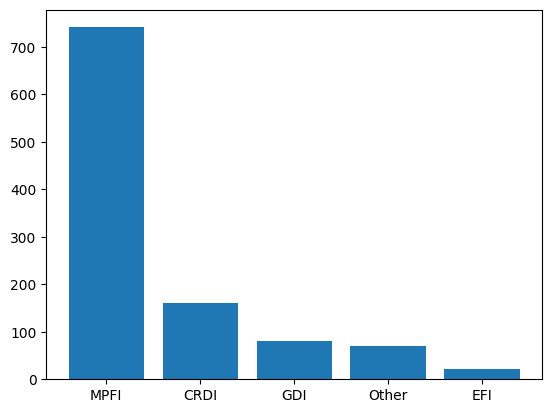

In [202]:
plt.bar(df['Fuel Supply System'].value_counts().index, df['Fuel Supply System'].value_counts().values)
plt.show()

In [203]:
df, dropped_fuel_sys = one_hot_encode_with_info(df, "Fuel Supply System", "FuelSys")


Feature: Fuel Supply System
All Categories: ['CRDI', 'EFI', 'GDI', 'MPFI', 'Other']
Dropped Category: CRDI


5. Fuel Type

In [204]:
df['Fuel Type'].fillna(df['Fuel Type'].mode()[0], inplace=True)
df['Fuel Type'].value_counts()

Fuel Type
Petrol      809
Diesel      231
CNG          28
Electric      6
Name: count, dtype: int64

In [205]:
# Drop all the row with 'Fuel Type' == 'Electric'
df = df[df['Fuel Type'] != 'Electric']

df, dropped_fuel_type = one_hot_encode_with_info(df, "Fuel Type", "Fuel")


Feature: Fuel Type
All Categories: ['CNG', 'Diesel', 'Petrol']
Dropped Category: CNG


6. 'Engine Type'

In [206]:
df['Engine Type'].fillna(df['Engine Type'].mode()[0], inplace=True)

In [207]:
def clean_engine_type(value):
    if pd.isna(value):
        return 'Unknown'
    
    value = str(value).strip()
    
    # Kappa variants
    if 'Kappa' in value or 'kappa' in value:
        return 'Kappa'
    
    # K-Series variants
    if any(x in value for x in ['K10B', 'K10C', 'K12M', 'K12N', 'K14B', 'K15B', 'K15C', 'K Series', 'K series', 'k-series', 'Advanced K']):
        return 'K Series'
    
    # i-VTEC variants (Honda Petrol)
    if any(x in value for x in ['i-VTEC', 'i VTEC', 'iVTEC', '1.2L i-VTEC', '1.2 i-VTEC']):
        return 'i-VTEC'
    
    # i-DTEC variants (Honda Diesel)
    if any(x in value for x in ['i-DTEC', 'i DTEC']):
        return 'i-DTEC'
    
    # Revotron variants (Tata Petrol)
    if any(x in value for x in ['Revotron', 'REVOTRON']):
        return 'Revotron'
    
    # Revotorq variants (Tata Diesel)
    if any(x in value for x in ['Revotorq', 'REVOTORQ']):
        return 'Revotorq'
    
    # DDiS variants (Maruti Diesel)
    if any(x in value for x in ['DDiS', 'DDIS']):
        return 'DDiS'
    
    # IRDE2 variants (Bajaj)
    if 'IRDE2' in value:
        return 'IRDE2'
    
    # TSI variants (Volkswagen Petrol)
    if 'TSI' in value:
        return 'TSI'
    
    # TDI/TDCi/TDCI variants (Diesel)
    if any(x in value for x in ['TDI', 'TDCi', 'TDCI']):
        return 'TDI'
    
    # CRDi/CRDI variants (Hyundai/Kia Diesel)
    if any(x in value for x in ['CRDi', 'CRDI', 'CRDe']):
        return 'CRDi'
    
    # mHawk variants (Mahindra Diesel)
    if any(x in value for x in ['mHawk', 'mHAWk']):
        return 'mHawk'
    
    # mStallion variants (Mahindra Petrol)
    if 'mStallion' in value:
        return 'mStallion'
    
    # Kryotec variants (Tata)
    if any(x in value for x in ['Kryotec', 'KRYOJET']):
        return 'Kryotec'
    
    # SmartStream variants (Hyundai)
    if any(x in value for x in ['SmartStream', 'SMARTSTREAM', 'Smartstream']):
        return 'SmartStream'
    
    # F8D variants (Maruti)
    if 'F8D' in value:
        return 'F8D'
    
    # VVT variants
    if any(x in value for x in ['VVT', 'VTVT', 'VVTi', 'Ti-VCT']):
        return 'VVT'
    
    # TwinPower (BMW)
    if 'TwinPower' in value:
        return 'TwinPower'
    
    # D-4D variants (Toyota Diesel)
    if any(x in value for x in ['D-4D', '2KD-FTV', '2-GD FTV']):
        return 'Toyota Diesel'
    
    # Generic Petrol
    if 'Petrol' in value or 'petrol' in value:
        return 'Petrol'
    
    # Generic Diesel
    if 'Diesel' in value or 'diesel' in value:
        return 'Diesel'
    
    # In-Line
    if 'In-Line' in value or 'In Line' in value or 'Inline' in value:
        return 'In-Line'
    
    return 'Other'


# Apply
df['Engine Type'] = df['Engine Type'].apply(clean_engine_type)

In [208]:
df['Engine Type'].value_counts()

Engine Type
Kappa            181
K Series         130
i-VTEC           108
Petrol           104
VVT               71
Other             67
Revotron          51
CRDi              46
In-Line           45
Diesel            39
DDiS              38
IRDE2             37
TSI               29
F8D               20
i-DTEC            16
SmartStream       15
mHawk             15
Toyota Diesel     13
TDI               13
Kryotec           12
Revotorq          10
mStallion          5
TwinPower          3
Name: count, dtype: int64

In [209]:
df, dropped_engine_type = one_hot_encode_with_info(
    df,
    "Engine Type",
    "EngineType"
)


Feature: Engine Type
All Categories: ['CRDi', 'DDiS', 'Diesel', 'F8D', 'IRDE2', 'In-Line', 'K Series', 'Kappa', 'Kryotec', 'Other', 'Petrol', 'Revotorq', 'Revotron', 'SmartStream', 'TDI', 'TSI', 'Toyota Diesel', 'TwinPower', 'VVT', 'i-DTEC', 'i-VTEC', 'mHawk', 'mStallion']
Dropped Category: CRDi


7. 'Emission Norm Compliance'

In [210]:
df['Emission Norm Compliance'].fillna(df['Emission Norm Compliance'].mode()[0], inplace=True)
df['Emission Norm Compliance'].value_counts()

Emission Norm Compliance
BS IV               578
BS VI               279
BS VI 2.0           147
Bharat Stage IV      26
BSIV                 21
Bharat Stage III     11
BS III                3
Euro VI               1
Euro IV               1
Euro V                1
Name: count, dtype: int64

In [211]:
def clean_emission_norm(x):

    if pd.isna(x):
        return None

    x = str(x).strip().lower()

    if "bs vi" in x or "bsvi" in x:
        return "BS6"

    elif "bs iv" in x or "bsiv" in x or "bharat stage iv" in x:
        return "BS4"

    elif "bs iii" in x or "bharat stage iii" in x:
        return "BS3"

    elif "euro" in x:
        return "EURO"

    else:
        return "Other"


df["Emission Norm Compliance"] = df["Emission Norm Compliance"].apply(clean_emission_norm)

In [212]:
df, dropped_emission_norm = one_hot_encode_with_info(df, "Emission Norm Compliance", "EmissionNorm")


Feature: Emission Norm Compliance
All Categories: ['BS3', 'BS4', 'BS6', 'EURO']
Dropped Category: BS3


8. 'Kerb Weight'

In [213]:
df['Kerb Weight'] = df['Kerb Weight'].str.extract(r'(\d+)').astype(float)

df['Kerb Weight'].fillna(df['Kerb Weight'].median(), inplace=True)

9. 'Drive Type'

In [214]:
# Filling missing with mode
df['Drive Type'].fillna(df['Drive Type'].mode()[0], inplace=True)

In [215]:
def clean_drive_type(value):
    value = str(value).strip().upper().replace(' ', '')
    
    fwd_variants = ['FWD', '2WD', '4X2', 'FRONTWHEELDRIVE', 'TWOWHEELDRIVE', 'TWOWHHEELDRIVE', 'TWOWHHHEELDRIVE']
    rwd_variants = ['RWD', 'RWD(WITHMTT)']
    awd_variants = ['AWD', '4WD', '4X4']
    
    if value in fwd_variants:
        return 'FWD'
    elif value in rwd_variants:
        return 'RWD'
    elif value in awd_variants:
        return 'AWD'
    else:
        return 'FWD'

# Apply
df['Drive Type'] = df['Drive Type'].apply(clean_drive_type)

In [216]:
df, droped_drive_type = one_hot_encode_with_info(df, "Drive Type", "DriveType")


Feature: Drive Type
All Categories: ['AWD', 'FWD', 'RWD']
Dropped Category: AWD


10. 'Transmission'

In [217]:
transmission_map = {
    "Automatic": 1,
    "Manual": 0 
}

df['Transmission'] = df['Transmission'].map(transmission_map)

df['Transmission'].fillna(df['Transmission'].mode()[0], inplace=True)

11. Power

In [218]:
df['Power'].head()

0       82 bhp
1    68.05 bhp
2       70 bhp
3    81.86 bhp
4     56.3 bhp
Name: Power, dtype: object

In [219]:
df['Power'] = df['Power'].str.replace(' bhp', '', regex=False).astype(float)

df['Power'].fillna(df['Power'].median(), inplace=True)

11. 'Valve Configuration'

In [220]:
df['Valve Configuration'].fillna(df['Valve Configuration'].mode()[0], inplace=True)

In [221]:
def clean_valve_config(value):
    value = str(value).strip().upper()
    
    if 'DOHC' in value:
        return 'DOHC'
    elif 'SOHC' in value:
        return 'SOHC'
    else:
        return value

df['Valve Configuration'] = df['Valve Configuration'].apply(clean_valve_config)
print(df['Valve Configuration'].value_counts())

Valve Configuration
DOHC    867
SOHC    198
IDSI      3
Name: count, dtype: int64


In [222]:
df, dropped_valve_config = one_hot_encode_with_info(df, "Valve Configuration", "ValveConfig")


Feature: Valve Configuration
All Categories: ['DOHC', 'IDSI', 'SOHC']
Dropped Category: DOHC


'engine_density'

In [223]:
df['Engine Density'] = df['Engine'] / df['No. of Cylinders']

df['Engine Density'].head()

0    299.25
1    271.50
2    299.00
3    299.25
4    312.00
Name: Engine Density, dtype: float64

In [224]:
df.columns

Index(['Engine', 'No. of Cylinders', 'Valves Per Cylinder', 'Kerb Weight',
       'Transmission', 'Power', 'FuelSys_EFI', 'FuelSys_GDI', 'FuelSys_MPFI',
       'FuelSys_Other', 'Fuel_Diesel', 'Fuel_Petrol', 'EngineType_DDiS',
       'EngineType_Diesel', 'EngineType_F8D', 'EngineType_IRDE2',
       'EngineType_In-Line', 'EngineType_K Series', 'EngineType_Kappa',
       'EngineType_Kryotec', 'EngineType_Other', 'EngineType_Petrol',
       'EngineType_Revotorq', 'EngineType_Revotron', 'EngineType_SmartStream',
       'EngineType_TDI', 'EngineType_TSI', 'EngineType_Toyota Diesel',
       'EngineType_TwinPower', 'EngineType_VVT', 'EngineType_i-DTEC',
       'EngineType_i-VTEC', 'EngineType_mHawk', 'EngineType_mStallion',
       'EmissionNorm_BS4', 'EmissionNorm_BS6', 'EmissionNorm_EURO',
       'DriveType_FWD', 'DriveType_RWD', 'ValveConfig_IDSI',
       'ValveConfig_SOHC', 'Engine Density'],
      dtype='object')

---

In [225]:
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer
from sklearn.metrics import r2_score, mean_absolute_error

In [226]:
bool_features = df.select_dtypes(include='bool').columns.tolist()

# Convert bool columns to int
df[bool_features] = df[bool_features].astype(int)

# Model
model = XGBRegressor(random_state=42)
model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [227]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 6, 10],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0]
}

grid_search = GridSearchCV(
    XGBRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

In [228]:
X = df.drop(columns=['Power'], axis=1)
y = df['Power']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [229]:
grid_search.fit(X_train, y_train)
best_model = grid_search.best_estimator_

In [230]:
 
best_model = grid_search.best_estimator_ 
y_pred = best_model.predict(X_test)

# 3. Quick evaluation
print(f"R2 Score: {r2_score(y_test, y_pred):.4f}")
print(f"Mean Absolute Error: {mean_absolute_error(y_test, y_pred):,.2f}")

R2 Score: 0.9320
Mean Absolute Error: 3.44


In [234]:
import os
import joblib
os.makedirs("model", exist_ok=True)
joblib.dump(best_model, "model/mileage_model.pkl")
print("Model saved!")

Model saved!


In [236]:
X_train.head(1)

,Engine,No. of Cylinders,Valves Per Cylinder,Kerb Weight,Transmission,FuelSys_EFI,FuelSys_GDI,FuelSys_MPFI,FuelSys_Other,Fuel_Diesel,...,EngineType_mHawk,EngineType_mStallion,EmissionNorm_BS4,EmissionNorm_BS6,EmissionNorm_EURO,DriveType_FWD,DriveType_RWD,ValveConfig_IDSI,ValveConfig_SOHC,Engine Density
915,1199.0,3.0,4.0,1066.0,0.0,0,0,1,0,0,...,0,0,0,1,0,1,0,0,0,399.666667


> In the next step we will be testing the model performance with different size of data